In [1]:
!pip install -q dagshub mlflow optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import dagshub
import mlflow
import optuna
import tensorflow as tf
import pandas as pd
import numpy as np

from tensorflow import keras

print("TensorFlow:", tf.__version__)
print("MLflow:", mlflow.__version__)
print("Optuna:", optuna.__version__)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("\n MNIST ")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

# Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# 3. Conexión con DAGSHUB


dagshub.init(
    repo_owner="Ainar",
    repo_name="Tareas-RDA",
    mlflow=True
)

mlflow.set_experiment("Tarea_2_MNIST_Optuna")

print("\n DAGSHUB / MLFLOW ")
print("Conexión establecida.")
print("Experimento:", "Tarea_2_MNIST_Optuna")


# Recuperación de las corridas

# Obtener el experimento actual
experiment = mlflow.get_experiment_by_name("Tarea_2_MNIST_Optuna")

print("\n EXPERIMENTO ")
print("Experiment ID:", experiment.experiment_id)
print("Nombre:", experiment.name)

# Recuperar todas las corridas existentes
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="pandas"
)

print("\n CORRIDAS RECUPERADAS ")
print("Número total de runs encontrados:", len(runs))

# Mostrar algunas columnas disponibles
columnas_interesantes = [
    "run_id",
    "status",
    "tags.regularizador",
    "tags.tipo_experimento",
    "tags.optuna_trial",
    "params.regularization",
    "params.l1_rate",
    "params.l2_rate",
    "params.dropout_rate",
    "metrics.best_val_accuracy",
    "metrics.best_val_loss"
]

columnas_disponibles = [
    c for c in columnas_interesantes
    if c in runs.columns
]

display(runs[columnas_disponibles].head(10))


# Construcción de la tabla comparativa

# Nos quedamos únicamente con los experimentos de regularización.
regularization_runs = runs[
    runs["tags.regularizador"].notna()
].copy()

print("\nRuns de regularización encontrados:",
      len(regularization_runs))

# Convertir métricas/hiperparámetros a numérico
for col in [
    "metrics.best_val_accuracy",
    "metrics.best_val_loss",
    "params.l1_rate",
    "params.l2_rate",
    "params.dropout_rate"
]:
    if col in regularization_runs.columns:
        regularization_runs[col] = pd.to_numeric(
            regularization_runs[col],
            errors="coerce"
        )

# Obtener el mejor trial de cada tipo de regularización
mejores = (
    regularization_runs
    .sort_values("metrics.best_val_accuracy", ascending=False)
    .groupby("tags.regularizador", as_index=False)
    .first()
)

# Seleccionar y renombrar columnas
tabla_mejores = mejores[
    [
        "tags.regularizador",
        "tags.optuna_trial",
        "params.l1_rate",
        "params.l2_rate",
        "params.dropout_rate",
        "metrics.best_val_accuracy",
        "metrics.best_val_loss"
    ]
].copy()

tabla_mejores = tabla_mejores.rename(columns={
    "tags.regularizador": "Regularización",
    "tags.optuna_trial": "Mejor Trial",
    "params.l1_rate": "L1",
    "params.l2_rate": "L2",
    "params.dropout_rate": "Dropout",
    "metrics.best_val_accuracy": "Mejor Val Accuracy",
    "metrics.best_val_loss": "Mejor Val Loss"
})

# Orden deseado
orden = [
    "L1",
    "L2",
    "L1-L2",
    "Dropout",
    "Dropout + L1-L2"
]

tabla_mejores["orden"] = (
    tabla_mejores["Regularización"]
    .map({nombre: i for i, nombre in enumerate(orden)})
)

tabla_mejores = (
    tabla_mejores
    .sort_values("orden")
    .drop(columns="orden")
    .reset_index(drop=True)
)

print("\n MEJORES RESULTADOS DE CADA REGULARIZACIÓN ")

display(
    tabla_mejores.style.format({
        "L1": lambda x: f"{x:.8f}" if pd.notna(x) else "—",
        "L2": lambda x: f"{x:.8f}" if pd.notna(x) else "—",
        "Dropout": lambda x: f"{x:.4f}" if pd.notna(x) else "—",
        "Mejor Val Accuracy": lambda x: f"{x:.4f}",
        "Mejor Val Loss": lambda x: f"{x:.4f}"
    })
)

TensorFlow: 2.20.0
MLflow: 3.16.0
Optuna: 5.0.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 MNIST 
x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ac9c9da9-63f4-47fd-84c9-791648ccc7a8&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=45de2ccbe0f2f20ea3cee39725353efca5627bb66fb0df7c7c7ca30ef8144c4d




Output()

Accessing as Ainar

...

Repository Ainar/Tareas-RDA initialized!


 DAGSHUB / MLFLOW 
Conexión establecida.
Experimento: Tarea_2_MNIST_Optuna

 EXPERIMENTO 
Experiment ID: 0
Nombre: Tarea_2_MNIST_Optuna

 CORRIDAS RECUPERADAS 
Número total de runs encontrados: 70


,run_id,status,tags.regularizador,tags.tipo_experimento,tags.optuna_trial,params.regularization,params.l1_rate,params.l2_rate,params.dropout_rate,metrics.best_val_accuracy,metrics.best_val_loss
0,e001e6a72bda484f83d0790fbdd543cb,FINISHED,Dropout + L1-L2,regularizacion,9,Dropout + L1-L2,0.00017955375181479365,9.458557306570721e-06,0.4768524584815318,0.971000,0.429834
1,41da31ebfe07447e9e8665fa5b9f474a,FINISHED,Dropout + L1-L2,regularizacion,8,Dropout + L1-L2,0.0003250662859752924,2.2955171852242277e-06,0.15514423686087092,0.975667,0.410630
2,2911ef5ad24a493ebc21164d706d972d,FINISHED,Dropout + L1-L2,regularizacion,7,Dropout + L1-L2,6.993037418018096e-06,1.5451841502760636e-05,0.23983528487782252,0.982333,0.146976
3,2115ada0e9384dbca6dc700554618cfa,FINISHED,Dropout + L1-L2,regularizacion,6,Dropout + L1-L2,1.070922683999918e-06,0.005311018227125352,0.2982533741574602,0.964667,0.344689
4,d6eda5fbcc9c451cafd33ae6533cdb75,FINISHED,Dropout + L1-L2,regularizacion,5,Dropout + L1-L2,0.0028909657869649196,0.0017844631783848304,0.2507049879861871,0.919833,1.759024
5,eb5cb4eae03d4e25bdd44e093255c194,FINISHED,Dropout + L1-L2,regularizacion,4,Dropout + L1-L2,6.587032208837969e-06,0.004603737808233088,0.17655966269208517,0.973500,0.279994
6,bc21ce5261e94b90ba1e077c0913b1f4,FINISHED,Dropout + L1-L2,regularizacion,3,Dropout + L1-L2,1.340580591468859e-05,1.698585037904463e-05,0.48544398991158244,0.979500,0.190483
7,94cf808651e945d99a7012fe4e133e06,FINISHED,Dropout + L1-L2,regularizacion,2,Dropout + L1-L2,0.0002855844434635064,0.00015645304227774562,0.17773460112628825,0.974833,0.386596
8,f1024fce23fa4d4da46087344863feb4,FINISHED,Dropout + L1-L2,regularizacion,1,Dropout + L1-L2,0.0003655099601251565,0.0012228683979291109,0.20953423063137683,0.968333,0.499187
9,0de44913f76046a9b62ccde7b91c32f8,FINISHED,Dropout + L1-L2,regularizacion,0,Dropout + L1-L2,2.4367987125114958e-06,0.002350424295584934,0.24529883014765452,0.974667,0.253205



Runs de regularización encontrados: 50

 MEJORES RESULTADOS DE CADA REGULARIZACIÓN 


,Regularización,Mejor Trial,L1,L2,Dropout,Mejor Val Accuracy,Mejor Val Loss
0,L1,1,0.00002780,—,—,0.9827,0.1421
1,L2,0,—,0.00019094,—,0.9845,0.1121
2,L1-L2,9,0.00000477,0.00002043,—,0.9833,0.1227
3,Dropout,0,—,—,0.2633,0.9850,0.0639
4,Dropout + L1-L2,7,0.00000699,0.00001545,0.2398,0.9823,0.1470


In [3]:
# Entrenamiento de los mejores modelos
EPOCHS = 10
BATCH_SIZE = 128
LEARNING_RATE = 0.0014593339089122514

#  Hiperparámetros óptimos encontrados por Optuna


best_params = {
    "L1": {
        "l1_rate": 0.00002780
    },
    "L2": {
        "l2_rate": 0.00019094
    },
    "L1-L2": {
        "l1_rate": 0.00000477,
        "l2_rate": 0.00002043
    },
    "Dropout": {
        "dropout_rate": 0.2633
    },
    "Dropout + L1-L2": {
        "l1_rate": 0.00000699,
        "l2_rate": 0.00001545,
        "dropout_rate": 0.2398
    }
}


# Construcción de la arquitectura


def build_regularized_model(regularization, params):

    model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten()
    ])

    if regularization == "L1":

        reg = keras.regularizers.L1(params["l1_rate"])

        model.add(
            keras.layers.Dense(
                512,
                activation="relu",
                kernel_regularizer=reg
            )
        )

        model.add(
            keras.layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=reg
            )
        )

        model.add(
            keras.layers.Dense(
                256,
                activation="relu",
                kernel_regularizer=reg
            )
        )

    elif regularization == "L2":

        reg = keras.regularizers.L2(params["l2_rate"])

        model.add(
            keras.layers.Dense(
                512,
                activation="relu",
                kernel_regularizer=reg
            )
        )

        model.add(
            keras.layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=reg
            )
        )

        model.add(
            keras.layers.Dense(
                256,
                activation="relu",
                kernel_regularizer=reg
            )
        )

    elif regularization == "L1-L2":

        reg = keras.regularizers.L1L2(
            l1=params["l1_rate"],
            l2=params["l2_rate"]
        )

        model.add(
            keras.layers.Dense(
                512,
                activation="relu",
                kernel_regularizer=reg
            )
        )

        model.add(
            keras.layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=reg
            )
        )

        model.add(
            keras.layers.Dense(
                256,
                activation="relu",
                kernel_regularizer=reg
            )
        )

    elif regularization == "Dropout":

        dropout = params["dropout_rate"]

        model.add(
            keras.layers.Dense(
                512,
                activation="relu"
            )
        )
        model.add(keras.layers.Dropout(dropout))

        model.add(
            keras.layers.Dense(
                64,
                activation="relu"
            )
        )
        model.add(keras.layers.Dropout(dropout))

        model.add(
            keras.layers.Dense(
                256,
                activation="relu"
            )
        )
        model.add(keras.layers.Dropout(dropout))

    elif regularization == "Dropout + L1-L2":

        reg = keras.regularizers.L1L2(
            l1=params["l1_rate"],
            l2=params["l2_rate"]
        )

        dropout = params["dropout_rate"]

        model.add(
            keras.layers.Dense(
                512,
                activation="relu",
                kernel_regularizer=reg
            )
        )
        model.add(keras.layers.Dropout(dropout))

        model.add(
            keras.layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=reg
            )
        )
        model.add(keras.layers.Dropout(dropout))

        model.add(
            keras.layers.Dense(
                256,
                activation="relu",
                kernel_regularizer=reg
            )
        )
        model.add(keras.layers.Dropout(dropout))

    # Capa de salida

    model.add(
        keras.layers.Dense(
            10,
            activation="softmax"
        )
    )

    # Compilación


    optimizer = keras.optimizers.RMSprop(
        learning_rate=LEARNING_RATE
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


#  Entrenamiento de los cinco mejores modelos


final_models = {}
final_histories = {}
final_results = []

for regularization, params in best_params.items():

    print("\n" + "=" * 60)
    print(f"ENTRENANDO: {regularization}")
    print("=" * 60)

    model = build_regularized_model(
        regularization,
        params
    )

    with mlflow.start_run(
        run_name=f"FINAL_{regularization.replace(' ', '_')}"
    ):

        mlflow.set_tag(
            "tipo_experimento",
            "modelo_final_regularizacion"
        )

        mlflow.set_tag(
            "regularizador",
            regularization
        )

        # Parámetros generales
        mlflow.log_param(
            "architecture",
            "512-64-256"
        )

        mlflow.log_param(
            "activation",
            "relu"
        )

        mlflow.log_param(
            "optimizer",
            "RMSprop"
        )

        mlflow.log_param(
            "learning_rate",
            LEARNING_RATE
        )

        mlflow.log_param(
            "epochs",
            EPOCHS
        )

        mlflow.log_param(
            "batch_size",
            BATCH_SIZE
        )

        # Parámetros de regularización
        for name, value in params.items():
            mlflow.log_param(name, value)

        # Entrenamiento
        history = model.fit(
            x_train,
            y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.1,
            verbose=1
        )

        # Evaluación en test
        test_loss, test_accuracy = model.evaluate(
            x_test,
            y_test,
            verbose=0
        )

        # Mejor validación
        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        best_val_loss = min(
            history.history["val_loss"]
        )

        # Registro de métricas
        mlflow.log_metric(
            "best_val_accuracy",
            best_val_accuracy
        )

        mlflow.log_metric(
            "best_val_loss",
            best_val_loss
        )

        mlflow.log_metric(
            "test_accuracy",
            test_accuracy
        )

        mlflow.log_metric(
            "test_loss",
            test_loss
        )

        # Métricas por época
        for epoch in range(EPOCHS):

            mlflow.log_metric(
                "train_accuracy",
                history.history["accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_accuracy",
                history.history["val_accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "train_loss",
                history.history["loss"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_loss",
                history.history["val_loss"][epoch],
                step=epoch
            )

    # Guardado en memoria
    final_models[regularization] = model
    final_histories[regularization] = history

    final_results.append({
        "Regularización": regularization,
        "Mejor Val Accuracy": best_val_accuracy,
        "Mejor Val Loss": best_val_loss,
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss
    })

    print(
        f"Mejor Val Accuracy: {best_val_accuracy:.4f}"
    )

    print(
        f"Test Accuracy:      {test_accuracy:.4f}"
    )

    print(
        f"Test Loss:          {test_loss:.4f}"
    )


# Tabla final


resultados_finales = pd.DataFrame(final_results)

print("\n" + "=" * 60)
print("RESULTADOS FINALES")
print("=" * 60)

display(
    resultados_finales.style.format({
        "Mejor Val Accuracy": "{:.4f}",
        "Mejor Val Loss": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Test Loss": "{:.4f}"
    })
)


ENTRENANDO: L1
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9115 - loss: 0.6111 - val_accuracy: 0.9688 - val_loss: 0.3328
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9641 - loss: 0.3136 - val_accuracy: 0.9693 - val_loss: 0.2806
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9722 - loss: 0.2508 - val_accuracy: 0.9665 - val_loss: 0.2642
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9762 - loss: 0.2133 - val_accuracy: 0.9765 - val_loss: 0.2062
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9790 - loss: 0.1851 - val_accuracy: 0.9743 - val_loss: 0.1995
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9808 - loss: 0.1667 - val_accuracy: 0.9763 - val_loss: 0.1867
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9832 - loss: 0.1517 - val_accuracy: 0.9810 - val_loss: 0.1621
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9834 - loss: 0

,Regularización,Mejor Val Accuracy,Mejor Val Loss,Test Accuracy,Test Loss
0,L1,0.9817,0.1487,0.9803,0.1512
1,L2,0.9798,0.1231,0.9706,0.1492
2,L1-L2,0.9830,0.1266,0.9743,0.1638
3,Dropout,0.9828,0.0606,0.9810,0.0807
4,Dropout + L1-L2,0.9820,0.1430,0.9796,0.1484


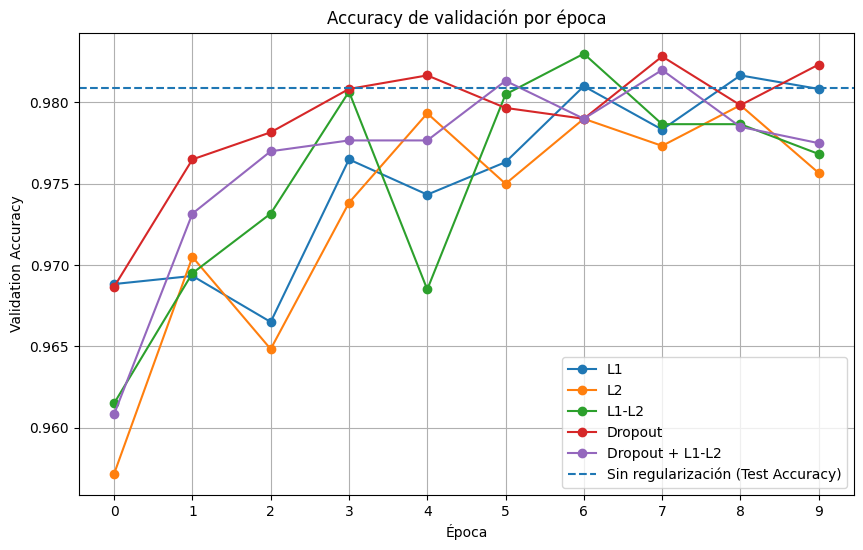

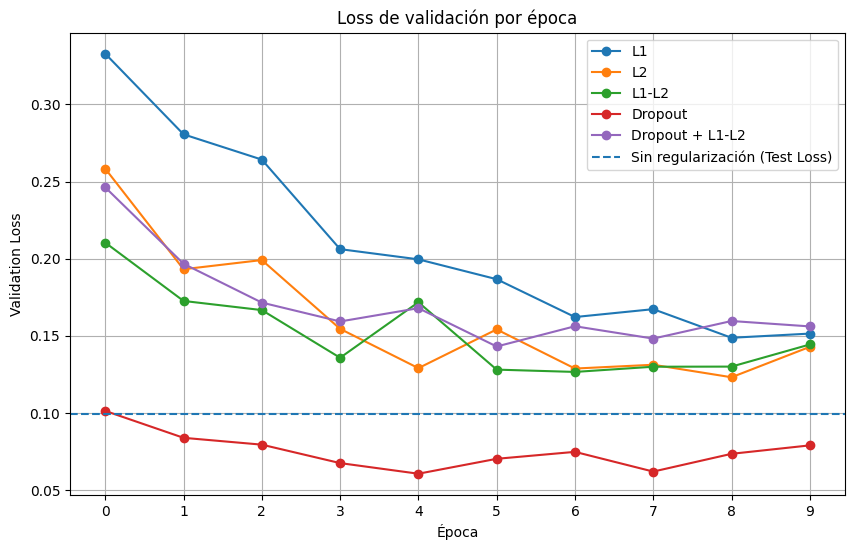

In [4]:
# Gráficas de entrenamiento y validación.

import matplotlib.pyplot as plt

# ACCURACY


plt.figure(figsize=(10, 6))

for regularization, history in final_histories.items():

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label=regularization
    )

plt.axhline(
    0.9809,
    linestyle="--",
    label="Sin regularización (Test Accuracy)"
)

plt.title("Accuracy de validación por época")
plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.xticks(range(10))
plt.legend()
plt.grid(True)

plt.show()


# LOSS


plt.figure(figsize=(10, 6))

for regularization, history in final_histories.items():

    plt.plot(
        history.history["val_loss"],
        marker="o",
        label=regularization
    )

plt.axhline(
    0.0992,
    linestyle="--",
    label="Sin regularización (Test Loss)"
)

plt.title("Loss de validación por época")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.xticks(range(10))
plt.legend()
plt.grid(True)

plt.show()

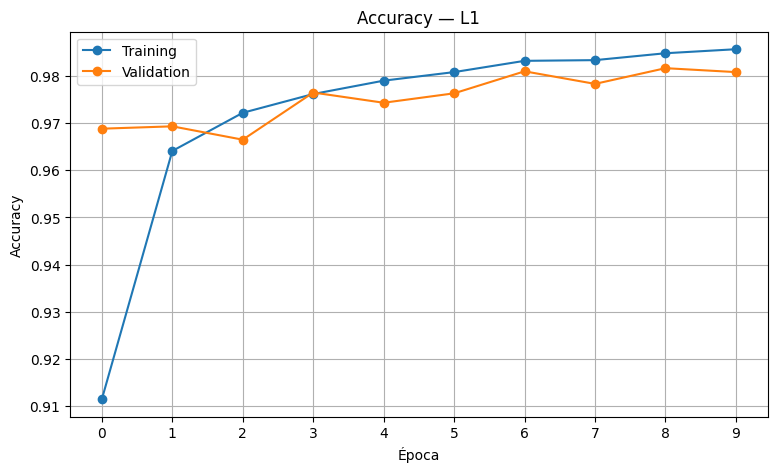

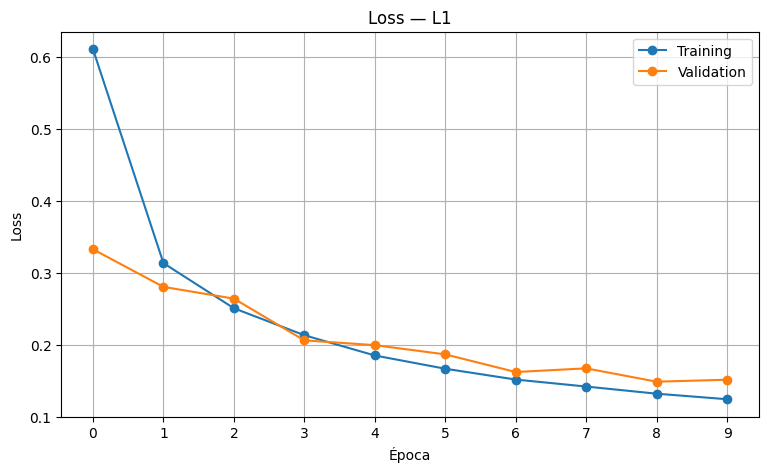

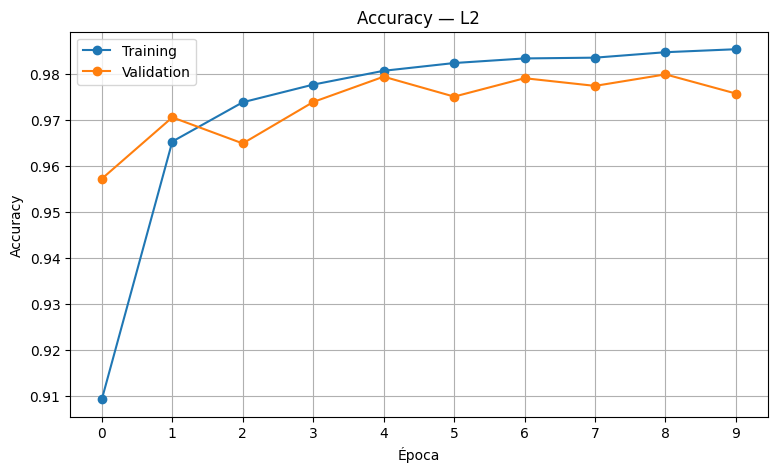

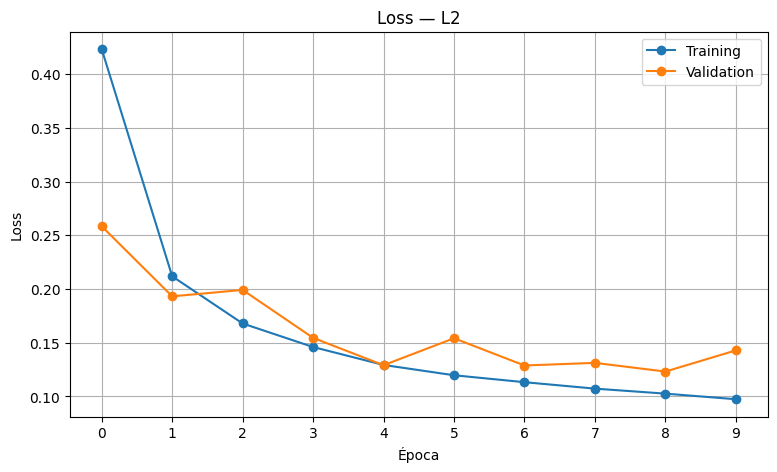

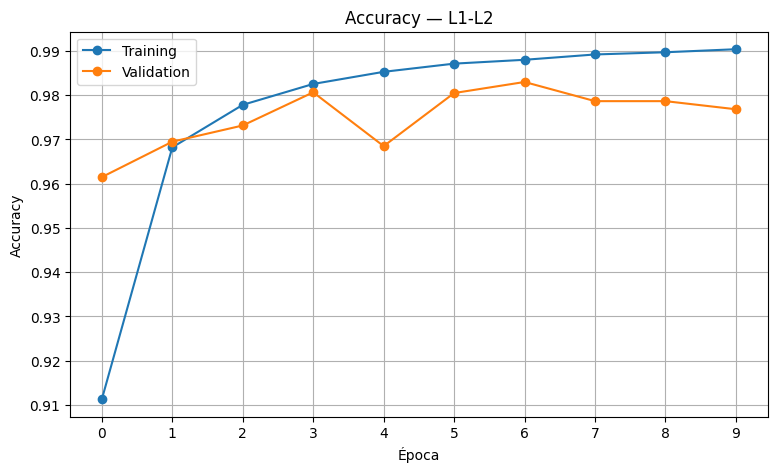

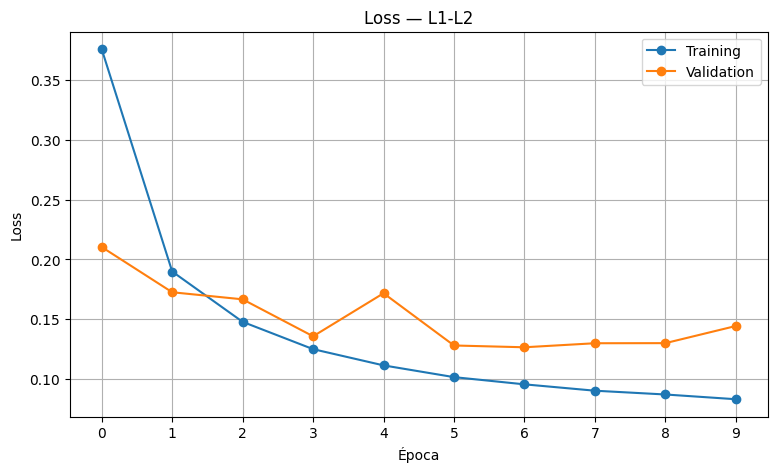

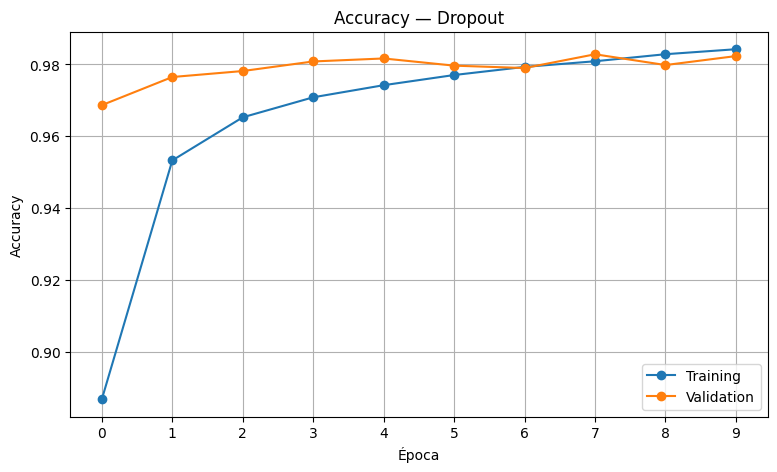

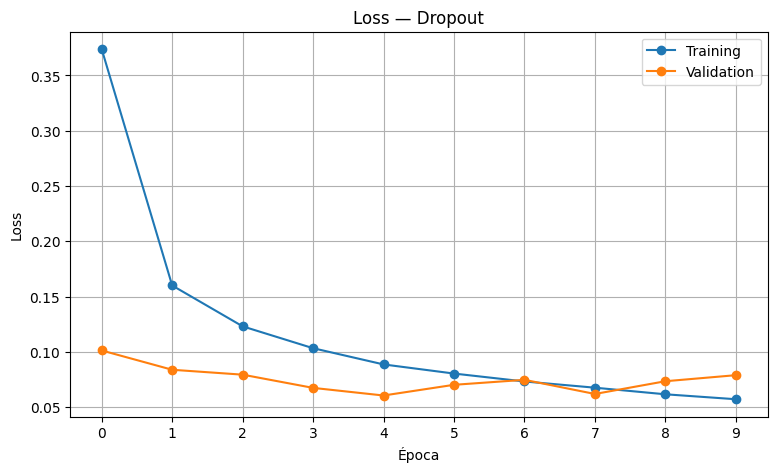

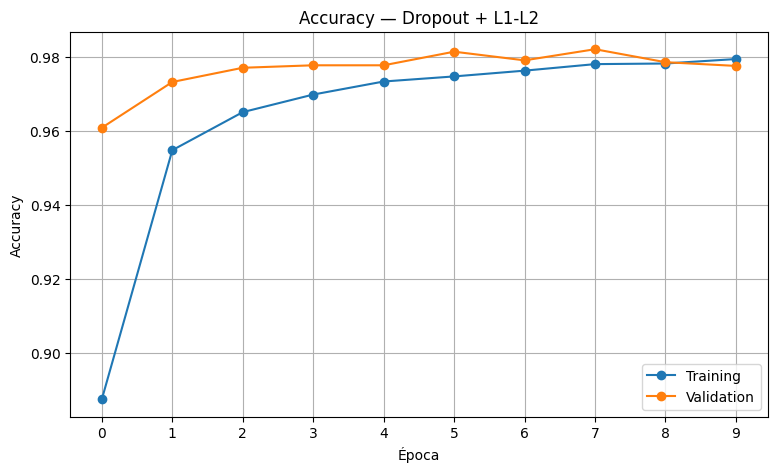

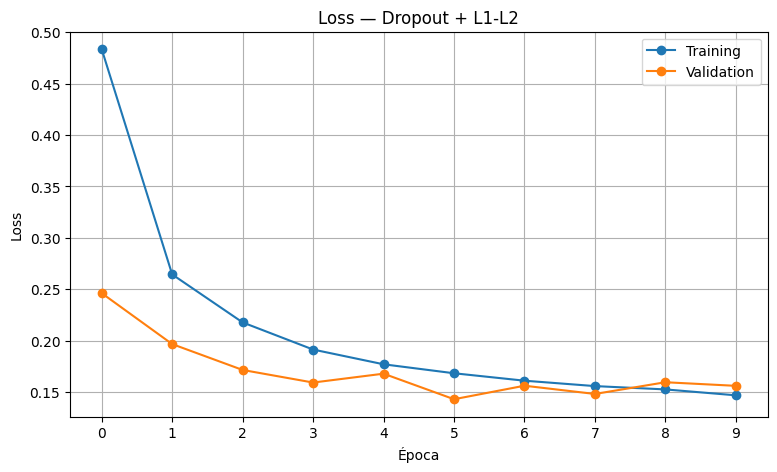

In [5]:
# Curvas de Training vs Validation

for regularization, history in final_histories.items():

    # Accuracy

    plt.figure(figsize=(9, 5))

    plt.plot(
        history.history["accuracy"],
        marker="o",
        label="Training"
    )

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label="Validation"
    )

    plt.title(
        f"Accuracy — {regularization}"
    )

    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.xticks(range(10))
    plt.legend()
    plt.grid(True)

    plt.show()

    # Loss


    plt.figure(figsize=(9, 5))

    plt.plot(
        history.history["loss"],
        marker="o",
        label="Training"
    )

    plt.plot(
        history.history["val_loss"],
        marker="o",
        label="Validation"
    )

    plt.title(
        f"Loss — {regularization}"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.xticks(range(10))
    plt.legend()
    plt.grid(True)

    plt.show()